# 🖼️ 3×3 Image Grid Assembler

Arranges sets of 9 images into seamless 3×3 grids.

**Naming convention:** files must end in `001`–`009` (e.g. `rose_001.jpg`, `rose_002.jpg` … `rose_009.jpg`).  
Upload as many sets as you like in one go — they are grouped automatically by their shared prefix.

**Grid layout:**
```
[ 009 ] [ 002 ] [ 003 ]
[ 008 ] [ 001 ] [ 004 ]
[ 007 ] [ 006 ] [ 005 ]
```

In [ ]:
# ── Cell 1: Install dependencies ─────────────────────────────────────────────
!pip install Pillow --quiet

In [ ]:
# ── Cell 2: Upload images ─────────────────────────────────────────────────────
from google.colab import files

print("Upload all your images now (multiple sets at once is fine).")
print("Files must end in 001–009, e.g.  rose_001.jpg, sunset_001.png …")
uploaded = files.upload()   # opens the file picker
print(f"\n✅  {len(uploaded)} file(s) uploaded.")

In [ ]:
# ── Cell 3: Group, build grids, preview & download ────────────────────────────
import os, re, io, zipfile
from collections import defaultdict
from PIL import Image
import IPython.display as display

# ── Grid placement map ────────────────────────────────────────────────────────
PLACEMENT = {
    1: (1, 1),  # center
    2: (0, 1),  # top middle
    3: (0, 2),  # top right
    4: (1, 2),  # middle right
    5: (2, 2),  # bottom right
    6: (2, 1),  # bottom middle
    7: (2, 0),  # bottom left
    8: (1, 0),  # middle left
    9: (0, 0),  # top left
}

VALID_EXT = {".jpg", ".jpeg", ".png", ".tiff", ".tif", ".bmp", ".webp"}

# ── Step 1: group uploaded files by their prefix ──────────────────────────────
# Prefix = everything before the last run of digits that equals 001-009
groups = defaultdict(dict)   # { prefix: { number: filename } }
skipped = []

for filename in uploaded:
    stem, ext = os.path.splitext(filename)
    if ext.lower() not in VALID_EXT:
        skipped.append(filename)
        continue

    # Extract 001-009 number and prefix, handling optional suffix like '_cp_masks'
    # The regex looks for:
    # ^(.*?)   - Group 1: Non-greedy match for everything before '_00'
    # _00([1-9]) - Group 2: The actual digit 1-9 after '_00'
    # (?:_.*)? - Non-capturing group for an optional suffix like '_cp_masks'
    m = re.search(r'^(.*?)_00([1-9])(?:_.*)?$', stem)
    if not m:
        skipped.append(filename)
        continue

    prefix = m.group(1)          # e.g. "rose" for "rose_001" or "B5.1P3R5_6WP_Day1_DS1_2026-06-15_4x" for "B5.1P3R5_6WP_Day1_DS1_2026-06-15_4x_001_cp_masks"
    num    = int(m.group(2))     # e.g. 1

    if not (1 <= num <= 9):
        skipped.append(filename)
        continue

    groups[prefix][num] = filename

print(f"Found {len(groups)} set(s): {list(groups.keys())}")
if skipped:
    print(f"⚠️  Skipped (no valid number suffix or unsupported type): {skipped}")


# ── Step 2: build a grid for each group ──────────────────────────────────────
def build_grid(group_name, file_map):
    """Assemble a 3×3 grid and return it as a PIL Image."""
    missing = [n for n in range(1, 10) if n not in file_map]
    if missing:
        print(f"  ⚠️  Missing image(s) {missing} — those cells will be black.")

    # Load images
    imgs = {}
    for num, fname in file_map.items():
        data = uploaded[fname]          # raw bytes from Colab upload
        imgs[num] = Image.open(io.BytesIO(data)).convert("RGB")

    # Cell size driven by image 001
    if 1 not in imgs:
        ref_num = min(imgs.keys())
        print(f"  ℹ️  Image 001 missing; using {ref_num:03d} as size reference.")
    else:
        ref_num = 1
    cell_w, cell_h = imgs[ref_num].size

    padding = 5 # Pixels to space out images

    # Calculate canvas dimensions including padding
    canvas_w = cell_w * 3 + padding * 2
    canvas_h = cell_h * 3 + padding * 2
    canvas = Image.new("RGB", (canvas_w, canvas_h), (255, 255, 255)) # Changed background to white

    for num, img in imgs.items():
        if img.size != (cell_w, cell_h):
            img = img.resize((cell_w, cell_h), Image.LANCZOS)
        row, col = PLACEMENT[num]

        # Calculate paste coordinates with padding
        x_offset = col * (cell_w + padding)
        y_offset = row * (cell_h + padding)
        canvas.paste(img, (x_offset, y_offset))

    return canvas


output_files = []   # collect paths for zip download

for prefix, file_map in groups.items():
    label = prefix.rstrip("_- ") or "grid"   # clean display name
    out_name = f"{label}_grid.jpg"
    print(f"\n{'─'*55}")
    print(f"Set: '{label}'  ({len(file_map)}/9 images)")

    grid = build_grid(label, file_map)
    grid.save(out_name, quality=95)
    output_files.append(out_name)
    print(f"  ✅  Saved → {out_name}  ({grid.width}×{grid.height} px)")

    # Inline preview (scaled to max 600 px wide)
    preview_w = min(600, grid.width)
    preview_h = int(grid.height * preview_w / grid.width)
    preview = grid.resize((preview_w, preview_h), Image.LANCZOS)
    buf = io.BytesIO()
    preview.save(buf, format="JPEG", quality=80)
    display.display(display.Image(data=buf.getvalue()))

print(f"\n{'═'*55}")
print(f"Done — {len(output_files)} grid(s) created.")

In [ ]:
import zipfile
from google.colab import files as colab_files
import os

# Ensure output_files is defined and contains paths to the generated images
if 'output_files' in globals() and output_files:
    zip_filename = "all_gridded_images.zip"

    with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zf:
        for f_path in output_files:
            if os.path.exists(f_path):
                zf.write(f_path, os.path.basename(f_path))
            else:
                print(f"Warning: File not found for zipping: {f_path}")

    print(f"Created {zip_filename} with {len(output_files)} gridded images. Downloading...")
    colab_files.download(zip_filename)
    print("Download complete!")
else:
    print("No gridded images were found to download. Please run the image grid assembly cell first.")


CLEAN MASKS

Upload your Cellpose mask files (.tif, .png, etc.) or a single .zip archive containing them:


Saving B5.1P3R5_6WP_Day2_DS1_2026-06-16_4x_grid_cp_masks.png to B5.1P3R5_6WP_Day2_DS1_2026-06-16_4x_grid_cp_masks.png
Saving B5.1P3R5_6WP_Day2_DS2_2026-06-16_4x_grid_cp_masks.png to B5.1P3R5_6WP_Day2_DS2_2026-06-16_4x_grid_cp_masks.png
Saving B5.1P3R5_6WP_Day2_DSPEG1_2026-06-16_4x_grid_cp_masks.png to B5.1P3R5_6WP_Day2_DSPEG1_2026-06-16_4x_grid_cp_masks.png
Saving B5.1P3R5_6WP_Day2_DSPEG2_2026-06-16_4x_grid_cp_masks.png to B5.1P3R5_6WP_Day2_DSPEG2_2026-06-16_4x_grid_cp_masks.png
Saving B5.1P3R5_6WP_Day2_HS1_2026-06-16_4x_grid_cp_masks.png to B5.1P3R5_6WP_Day2_HS1_2026-06-16_4x_grid_cp_masks.png
Saving B5.1P3R5_6WP_Day2_HS2_2026-06-16_4x_grid_cp_masks.png to B5.1P3R5_6WP_Day2_HS2_2026-06-16_4x_grid_cp_masks.png
Saving B5.1P3R5_6WP_Day2_HSPEG1_2026-06-16_4x_grid_cp_masks.png to B5.1P3R5_6WP_Day2_HSPEG1_2026-06-16_4x_grid_cp_masks.png
Saving B5.1P3R5_6WP_Day2_HSPEG2_2026-06-16_4x_grid_cp_masks.png to B5.1P3R5_6WP_Day2_HSPEG2_2026-06-16_4x_grid_cp_masks.png
Saving B5.1P3R5_6WP_Day2_NEG1_20

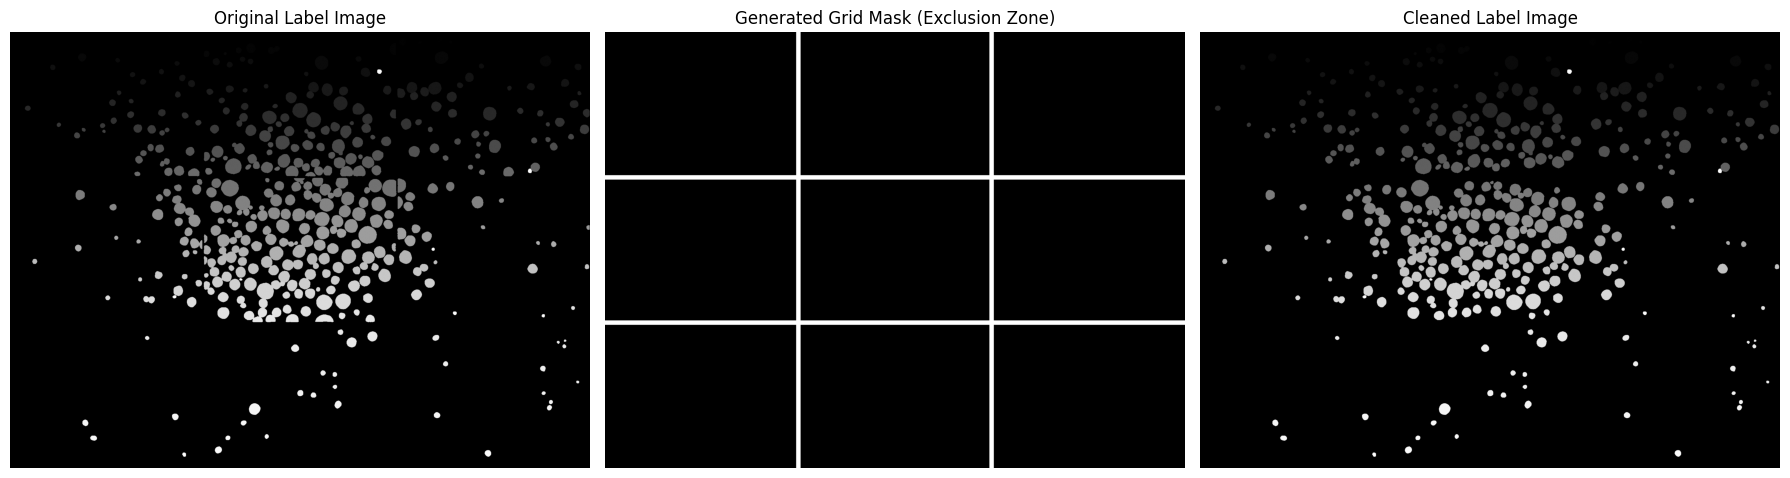

    ✅ Saved cleaned mask to cleaned_masks/B5.1P3R5_6WP_Day2_DS1_2026-06-16_4x_grid_cp_cleared_grid_masks.tif
  Processing: B5.1P3R5_6WP_Day2_DS2_2026-06-16_4x_grid_cp_masks.png
--- Debugging grid cleaning for: B5.1P3R5_6WP_Day2_DS2_2026-06-16_4x_grid_cp_masks.png ---


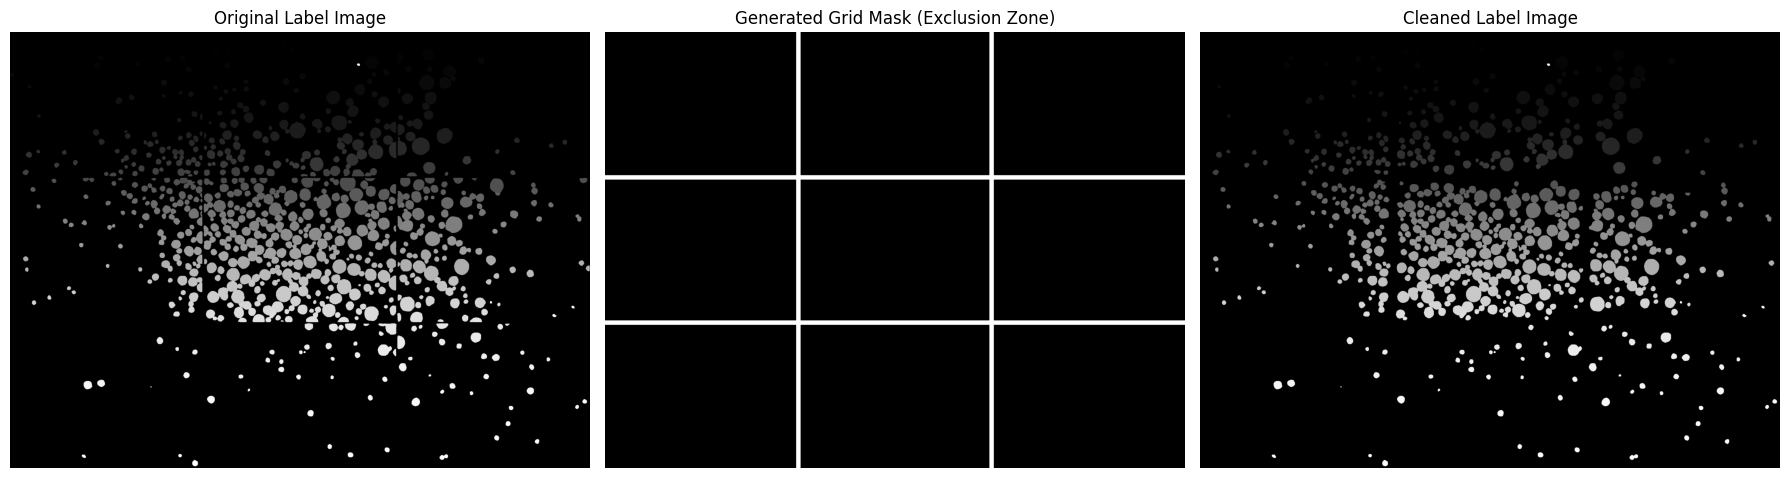

    ✅ Saved cleaned mask to cleaned_masks/B5.1P3R5_6WP_Day2_DS2_2026-06-16_4x_grid_cp_cleared_grid_masks.tif
  Processing: B5.1P3R5_6WP_Day2_DSPEG1_2026-06-16_4x_grid_cp_masks.png
--- Debugging grid cleaning for: B5.1P3R5_6WP_Day2_DSPEG1_2026-06-16_4x_grid_cp_masks.png ---


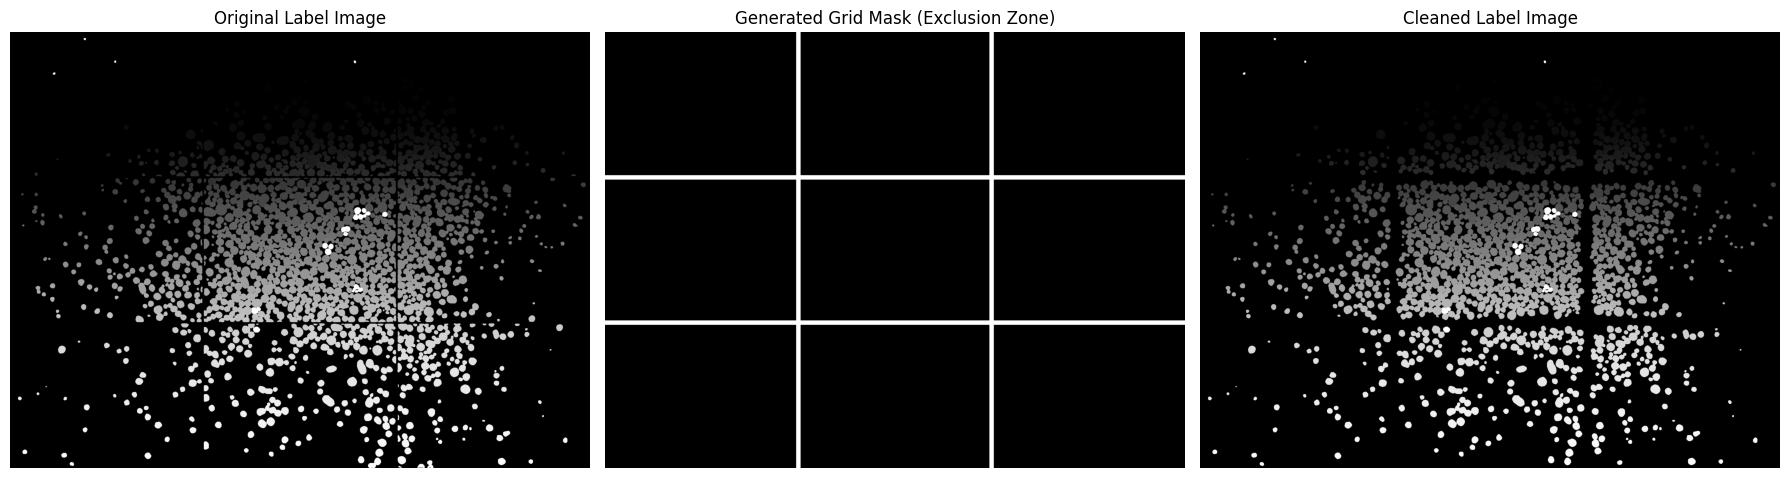

    ✅ Saved cleaned mask to cleaned_masks/B5.1P3R5_6WP_Day2_DSPEG1_2026-06-16_4x_grid_cp_cleared_grid_masks.tif
  Processing: B5.1P3R5_6WP_Day2_DSPEG2_2026-06-16_4x_grid_cp_masks.png
    ✅ Saved cleaned mask to cleaned_masks/B5.1P3R5_6WP_Day2_DSPEG2_2026-06-16_4x_grid_cp_cleared_grid_masks.tif
  Processing: B5.1P3R5_6WP_Day2_HS1_2026-06-16_4x_grid_cp_masks.png
    ✅ Saved cleaned mask to cleaned_masks/B5.1P3R5_6WP_Day2_HS1_2026-06-16_4x_grid_cp_cleared_grid_masks.tif
  Processing: B5.1P3R5_6WP_Day2_HS2_2026-06-16_4x_grid_cp_masks.png
    ✅ Saved cleaned mask to cleaned_masks/B5.1P3R5_6WP_Day2_HS2_2026-06-16_4x_grid_cp_cleared_grid_masks.tif
  Processing: B5.1P3R5_6WP_Day2_HSPEG1_2026-06-16_4x_grid_cp_masks.png
    ✅ Saved cleaned mask to cleaned_masks/B5.1P3R5_6WP_Day2_HSPEG1_2026-06-16_4x_grid_cp_cleared_grid_masks.tif
  Processing: B5.1P3R5_6WP_Day2_HSPEG2_2026-06-16_4x_grid_cp_masks.png
    ✅ Saved cleaned mask to cleaned_masks/B5.1P3R5_6WP_Day2_HSPEG2_2026-06-16_4x_grid_cp_cleared_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete!

✨ Script execution finished.


In [ ]:
import io
import os
import re
import zipfile
import shutil
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
from PIL import Image
import IPython.display as display
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile as tf

from google.colab import files as colab_files

# ==========================================
# Global Configuration Parameters
# ==========================================_
DIAMETER_MIN_FILTER = None         # Set to a value (e.g., 10) to filter out small debris
VALID_IMAGE_EXTENSIONS = {'.tif', '.png', '.jpg', '.jpeg', '.bmp'} # Supported image file extensions
EXCLUDE_CONDITIONS = ['DSPVA2']     # List of experiment conditions to exclude

# Debugging flag for grid cleaning visualization
# Set to a positive integer (e.g., 3) to show debug plots for the first N cleaned images.
_DEBUG_OUTPUT_GRID_CLEANING_IMAGES_COUNT = 3


# ==========================================
# Helper & Metadata Parsing Functions
# ==========================================
def natural_sort_key(s):
    """Sorts string categories with numbers logically (e.g., Day2, Day3, Day10)"""
    if pd.isna(s):
        return []
    return [int(t) if t.isdigit() else t.lower() for t in re.split('([0-9]+)', str(s))]

def parse_filename_metadata(clean_label):
    """Extracts experimental variables dynamically from standard file names."""
    match = re.match(r'(.+?)_(.+?)_(Day\d+)_(.+?)_(\d{4}-\d{2}-\d{2})_(\d+x).*', clean_label)
    if match:
        return pd.Series({
            'BATCH': match.group(1), 'PLATE': match.group(2), 'DAY': match.group(3),
            'Condition': match.group(4), 'DATE': match.group(5), 'Magnification': match.group(6)
        })
    return pd.Series({k: None for k in ['BATCH','PLATE','DAY','Condition','DATE','Magnification']})

def detect_and_clean_grid_cellpose(label_img, file_name, debug_counter):
    """
    Identifies if a mask is a 3x3 or 5x5 layout dynamically,
    and clears out all cell masks that border or cross grid lines, or are within a small buffer distance from image edges.
    """
    h, w = label_img.shape
    binary_mask = (label_img > 0).astype(np.uint8) * 255
    grid_mask = np.zeros_like(binary_mask)

    # Determine grid type based on specific dimensions or file name heuristics
    # These dimensions are based on typical image sizes from certain microscopes or stitching processes.
    if (h == 1468 and w == 1954) or (h == 1954 and w == 1468): # Specific 3x3 resolution (e.g., 20x)
        grid_rows, grid_cols = 3, 3
        pixel_size = 800.0 / 183.0   # distance=183, known=800 µm (3x3 scale)
        grid_type = "3x3"
    elif (h == 2132 and w == 2496) or (h == 2496 and w == 2132): # Specific 5x5 resolution (e.g., 10x)
        grid_rows, grid_cols = 5, 5
        pixel_size = 1000.0 / 183.0  # distance=183, known=1000 µm (5x5 scale)
        grid_type = "5x5"
    # New heuristic for 5x5: image is significantly bigger than a 3x3 standard
    elif (h > 1468 + 100 and w > 1954 + 100) or (w > 1468 + 100 and h > 1954 + 100):
        grid_rows, grid_cols = 5, 5
        pixel_size = 1000.0 / 183.0  # distance=183, known=1000 µm (5x5 scale)
        grid_type = "5x5"
    elif "_grid.jpg" in file_name.lower() or "_grid_masks.tif" in file_name.lower(): # Check for stitched image suffix
        grid_rows, grid_cols = 3, 3
        pixel_size = 800.0 / 183.0   # distance=183, known=800 µm (3x3 scale)
        grid_type = "3x3"
    # Heuristic for automated microscope or very large images
    elif "ZEN" in file_name.lower() or h > 4000 or w > 4000:
        grid_rows, grid_cols = 5, 5
        pixel_size = 1000.0 / 183.0  # distance=183, known=1000 µm (5x5 scale)
        grid_type = "5x5"
    else: # Default to 3x3 if no clear indication for 5x5
        grid_rows, grid_cols = 3, 3
        pixel_size = 200  / 45.5   # distance=183, known=800 µm (3x3 scale)  -- Placeholder, adjust as needed
        grid_type = "3x3"

    # Construct mathematical grid layout boundaries
    # These lines are typically 5 pixels thick to catch objects touching the boundary
    for i in range(1, grid_rows):
        y = int(i * h / grid_rows)
        cv2.line(grid_mask, (0, y), (w, y), 255, thickness=5)
    for j in range(1, grid_cols):
        x = int(j * w / grid_cols)
        cv2.line(grid_mask, (x, 0), (x, h), 255, thickness=5)

    # Apply morphological dilation to expand the grid_mask further (e.g., 4 iterations for 3x3 kernel)
    kernel = np.ones((3, 3), np.uint8)
    grid_mask = cv2.dilate(grid_mask, kernel, iterations=4)

    # Drop individual cell components intersecting the boundary line grid OR touching image edges
    cleaned_label_img = np.copy(label_img)
    unique_labels = np.unique(label_img)

    # Define buffer for edge detection (e.g., 2 pixels from the edge)
    edge_buffer_pixels = 2

    for label_val in unique_labels:
        if label_val == 0:
            continue
        cell_coords = (label_img == label_val)

        # Check for intersection with grid_mask
        intersects_grid = np.any(grid_mask[cell_coords] > 0)

        # Check for touching image edges within the defined buffer
        # Get min/max row/col of the current cell
        rows, cols = np.where(cell_coords)
        touches_edge = False
        if rows.size > 0 and cols.size > 0: # Ensure there are coordinates for the label
            if np.min(rows) < edge_buffer_pixels or np.max(rows) >= (h - edge_buffer_pixels) or \
               np.min(cols) < edge_buffer_pixels or np.max(cols) >= (w - edge_buffer_pixels):
                touches_edge = True

        if intersects_grid or touches_edge:
            cleaned_label_img[cell_coords] = 0

    if debug_counter > 0:
        print(f"--- Debugging grid cleaning for: {file_name} ---")

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        axes[0].imshow(label_img, cmap='gray')
        axes[0].set_title("Original Label Image")
        axes[0].axis('off')

        axes[1].imshow(grid_mask, cmap='gray')
        axes[1].set_title("Generated Grid Mask (Exclusion Zone)")
        axes[1].axis('off')

        axes[2].imshow(cleaned_label_img, cmap='gray')
        axes[2].set_title("Cleaned Label Image")
        axes[2].axis('off')
        plt.tight_layout()
        plt.show()

    return cleaned_label_img, pixel_size, grid_type


# ==========================================
# File Upload and Extraction Function
# ==========================================
def upload_and_extract_images():
    print("Upload your Cellpose mask files (.tif, .png, etc.) or a single .zip archive containing them:")
    uploaded_files = colab_files.upload()

    if not uploaded_files:
        print("Pipeline stopped: No files selected.")
        return {}, None, 0

    all_image_data = {}
    temp_dir = None
    processed_count = 0

    # Check if a single zip file was uploaded
    zip_files = [f for f in uploaded_files.keys() if f.lower().endswith('.zip')]

    if len(zip_files) == 1:
        zip_filename = zip_files[0]
        zip_bytes = uploaded_files[zip_filename]
        print(f"Detected zip archive: {zip_filename}. Extracting...")

        temp_dir = "temp_extracted_images"
        os.makedirs(temp_dir, exist_ok=True)

        try:
            with zipfile.ZipFile(io.BytesIO(zip_bytes), 'r') as zf:
                for member in zf.namelist():
                    if not member.startswith('__MACOSX/') and not member.startswith('._'): # Skip macOS specific junk
                        _, ext = os.path.splitext(member)
                        if ext.lower() in VALID_IMAGE_EXTENSIONS:
                            # Extract to temp_dir and then read bytes
                            zf.extract(member, temp_dir)
                            full_path = os.path.join(temp_dir, member)
                            with open(full_path, 'rb') as f:
                                all_image_data[member] = f.read()
                            processed_count += 1
                            print(f"  Extracted: {member}")
        except zipfile.BadZipFile:
            print(f"Error: {zip_filename} is not a valid zip file. Please upload a valid zip archive.")
            if temp_dir and os.path.exists(temp_dir):
                shutil.rmtree(temp_dir)
            return {}, None, 0
        except Exception as e:
            print(f"An unexpected error occurred during zip extraction: {e}")
            if temp_dir and os.path.exists(temp_dir):
                shutil.rmtree(temp_dir)
            return {}, None, 0

    else:
        # Process individual image files directly uploaded
        for file_name, file_bytes in uploaded_files.items():
            _, ext = os.path.splitext(file_name)
            if ext.lower() in VALID_IMAGE_EXTENSIONS:
                all_image_data[file_name] = file_bytes
                processed_count += 1
            else:
                print(f"Skipping non-image file: {file_name}")

    if not all_image_data:
        print("No valid image files found after upload or extraction. Please ensure your zip contains images or upload images directly.")
        if temp_dir and os.path.exists(temp_dir):
            shutil.rmtree(temp_dir)
        return {}, None, 0

    print(f"\n\u2705  {processed_count} image file(s) found for processing.")
    return all_image_data, temp_dir, processed_count


# ==========================================
# Grid Cleaning and Saving Cleaned Masks
# ==========================================
def perform_grid_cleaning(raw_image_data_dict, output_base_dir="cleaned_masks"):
    """Performs grid cleaning on raw masks and saves the cleaned results."""
    cleaned_metadata = {}
    output_dir = os.path.join(output_base_dir)
    os.makedirs(output_dir, exist_ok=True)

    print(f"\nStarting grid cleaning and saving cleaned masks to '{output_dir}'...")

    debug_plot_count = _DEBUG_OUTPUT_GRID_CLEANING_IMAGES_COUNT

    for file_name, file_bytes in raw_image_data_dict.items():
        print(f"  Processing: {file_name}")
        try:
            nparr = np.frombuffer(file_bytes, np.uint8)
            label_img = cv2.imdecode(nparr, cv2.IMREAD_UNCHANGED)

            if label_img is None:
                print(f"    Error: Could not decode image data for {file_name}. Skipping.")
                continue

            # If it's a multi-channel image, assume the first channel is the label map
            if len(label_img.shape) == 3:
                label_img = label_img[:, :, 0]

            cleaned_labels, pixel_size, grid_type = detect_and_clean_grid_cellpose(label_img, file_name, debug_plot_count)
            if debug_plot_count > 0: # Decrement debug counter after each plot
                debug_plot_count -= 1

            # Construct the new filename for the cleaned mask
            base_name, ext = os.path.splitext(file_name)
            # Remove '_masks' if it's at the end before adding '_cleared_grid_masks'
            if base_name.lower().endswith('_masks'):
                cleaned_base_name = base_name.rsplit('_masks', 1)[0]
            else:
                cleaned_base_name = base_name

            cleaned_file_name = f"{os.path.basename(cleaned_base_name)}_cleared_grid_masks.tif" # Force .tif for masks

            output_path = os.path.join(output_dir, cleaned_file_name)
            cleaned_labels_to_save = cleaned_labels.astype(np.uint16) # Ensure it's uint16 for TIFF

            tf.imwrite(output_path, cleaned_labels_to_save)
            print(f"    \u2705 Saved cleaned mask to {output_path}")

            # Store metadata and bytes for potential further in-memory processing or direct use
            with open(output_path, 'rb') as f_read:
                cleaned_metadata[cleaned_file_name] = {
                    'original_filename': file_name,
                    'file_path': output_path,
                    'pixel_size': pixel_size,
                    'grid_type': grid_type,
                    'bytes': f_read.read() # Read bytes back into memory
                }

        except Exception as e:
            print(f"    \u26a0\ufe0f Skipping cleaning for {file_name} due to error: {e}")

    if not cleaned_metadata:
        print("No masks were successfully cleaned or saved.")

    return cleaned_metadata, output_dir


# ==========================================
# Download Cleaned Masks
# ==========================================
def download_cleaned_masks_zip(cleaned_masks_dir, processed_file_count):
    """Creates a zip archive of all cleaned masks and offers it for download."""
    if not os.path.exists(cleaned_masks_dir) or not os.listdir(cleaned_masks_dir):
        print(f"No cleaned masks found in '{cleaned_masks_dir}' to download.")
        return

    zip_filename = f"cleaned_grid_masks_{processed_file_count}_masks.zip"

    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, _, files_in_dir in os.walk(cleaned_masks_dir):
            for file_in_dir in files_in_dir:
                full_path = os.path.join(root, file_in_dir)
                zipf.write(full_path, arcname=os.path.relpath(full_path, cleaned_masks_dir))

    print(f"\n\U0001f4e6 Created archive: {zip_filename}. Downloading...")
    colab_files.download(zip_filename)
    print("Download complete!")

    # Clean up the generated zip file after download
    # if os.path.exists(zip_filename):
    #     os.remove(zip_filename)


# ==========================================
# Main Execution Flow
# ==========================================

# Step 1: Upload and extract images
raw_uploaded_data, temp_extracted_zip_dir, processed_file_count = upload_and_extract_images()

if raw_uploaded_data:
    # Step 2: Perform grid cleaning and save cleaned masks
    cleaned_masks_data, cleaned_masks_output_dir = perform_grid_cleaning(raw_uploaded_data)

    if cleaned_masks_data:
        # Step 3: Download cleaned masks
        download_cleaned_masks_zip(cleaned_masks_output_dir, processed_file_count)

    else:
        print("No cleaned masks were generated.")

else:
    print("No valid image data was uploaded for cleaning.")


print("\n\u2728 Script execution finished.")

### Cleanup Temporary Directories

Run this cell after you have downloaded your `cleaned_grid_masks.zip` file to remove the temporary directories and files created during the process.

In [ ]:
import os
import shutil
import re

deleted_count = 0

# List all files and directories in the current working directory
all_items = os.listdir('/content/')

# Known directories to clean up (e.g., from 'Clean Masks' section)
# These are handled as a fail-safe, as cab9c94f should clean its own outputs.
known_dirs_to_delete = {"cleaned_masks", "temp_extracted_images"}

for item in all_items:
    item_path = os.path.join('/content/', item)

    if os.path.isdir(item_path):
        if item in known_dirs_to_delete:
            try:
                shutil.rmtree(item_path)
                print(f"  Deleted directory: {item}/")
                deleted_count += 1
            except OSError as e:
                print(f"  Error deleting directory {item}: {e}")
    elif os.path.isfile(item_path):
        # Patterns for files to delete:
        # 1. Original uploaded images (e.g., image_001.jpg, image_001 (1).jpg)
        #    Identified by '_00X' suffix and potential '(N)' for Colab duplicates.
        #    Covers common image extensions.
        image_input_pattern = re.compile(r'.+_00[1-9](\s\(\d+\))?\.(jpg|jpeg|png|tif|tiff|bmp|webp)$', re.IGNORECASE)
        # 2. Generated grid images (e.g., prefix_grid.jpg, prefix_grid (1).jpg)
        grid_output_pattern = re.compile(r'.+_grid(\s\(\d+\))?\.(jpg|jpeg|png|tif|tiff|bmp|webp)$', re.IGNORECASE)
        # 3. Uploaded Cellpose masks (e.g., prefix_grid_cp_masks.png or with Colab's (N) suffix)
        cellpose_uploaded_mask_pattern = re.compile(r'.+_grid_cp_masks(\s\(\d+\))?\.(png|tif|tiff|jpg|jpeg|bmp|webp)$', re.IGNORECASE)
        # 4. Generated zip files (e.g., all_gridded_images.zip, custom_name.zip)
        zip_file_pattern = re.compile(r'.*\.zip$', re.IGNORECASE)
        # 5. Cleaned mask TIFF files (e.g., original_cleared_grid_masks.tif), might be in /content/ if output dir was not specified.
        cleaned_mask_tif_pattern = re.compile(r'.+_cleared_grid_masks\.tif$', re.IGNORECASE)

        if (image_input_pattern.match(item) or
            grid_output_pattern.match(item) or
            cellpose_uploaded_mask_pattern.match(item) or # New pattern added here
            zip_file_pattern.match(item) or
            cleaned_mask_tif_pattern.match(item)):
            try:
                os.remove(item_path)
                print(f"  Deleted file: {item}")
                deleted_count += 1
            except OSError as e:
                print(f"  Error deleting file {item}: {e}")

print(f"\nCleanup complete. Total {deleted_count} items removed (files and directories).")

  Deleted file: B5.1P3R6_6WP_DAY2_DSPVA_2026-07-07_4x_grid_cp_masks.png
  Deleted file: B5.1P3R6_6WP_DAY5_NEG_2026-07-10_4x_grid_cp_masks.png
  Deleted file: B5.1P3R6_6WP_DAY5_DSPEG_2026-07-10_4x_grid_cp_masks.png
  Deleted file: B5.1P3R6_6WP_DAY4_DS_2026-07-09_4x_grid_cp_masks.png
  Deleted file: B5.1P3R6_6WP_DAY3_DSPEG_2026-07-08_4x_grid_cp_masks.png
  Deleted file: B5.1P3R6_6WP_DAY4_PVA_2026-07-09_4x_grid_cp_masks.png
  Deleted file: B5.1P3R6_6WP_DAY4_DSPEG_2026-07-09_4x_grid_cp_masks.png
  Deleted file: B5.1P3R6_6WP_DAY3_PVA_2026-07-08_4x_grid_cp_masks.png
  Deleted file: B5.1P3R6_6WP_DAY4_DSPVA_2026-07-09_4x_grid_cp_masks.png
  Deleted file: B5.1P3R6_6WP_DAY5_PEG_2026-07-10_4x_grid_cp_masks.png
  Deleted file: B5.1P3R6_6WP_DAY4_PEG_2026-07-09_4x_grid_cp_masks.png
  Deleted file: B5.1P3R6_6WP_DAY3_PEG_2026-07-08_4x_grid_cp_masks.png
  Deleted file: B5.1P3R6_6WP_DAY5_DS_2026-07-10_4x_grid_cp_masks.png
  Deleted file: B5.1P3R6_6WP_DAY2_NEG_2026-07-07_4x_grid_cp_masks.png
  Deleted fi